In [168]:
import numpy as np         
import csv                  
import matplotlib.pyplot as plt  
import random              
import os
np.random.seed()
random.seed()

In [169]:
CSV_PATH      = 'pima-indians-diabetes.csv'
HAS_HEADER    = True
LABEL_COL     = 8
POSITIVE_CLASS = '1'
TRAIN_RATIO   = 0.80

ETA               = 0.1
SUCCESS_THRESHOLD = 0.85
MAX_EPOCHS        = 5000


HIDDEN_CONFIGS = [
    [4], [8], [16], [8, 4], [16, 8], [8, 8, 4],
]

In [172]:
def load_dataset(path, has_header, label_col, positive_class):
   
    rows = []
    with open(path, 'r') as f:
        reader = csv.reader(f)
        if has_header:
            next(reader)
        for line in reader:
            if line and len(line) > 1:
                try:
                    [float(v) for v in line] 
                    rows.append(line)
                except ValueError:
                    pass

    X_list, y_list = [], []
    for row in rows:
      
        features = [float(row[i]) for i in range(len(row)) if i != label_col]
        label_raw = row[label_col].strip()

       
        label = 1.0 if label_raw == positive_class else -1.0

        X_list.append(features)
        y_list.append(label)

    X = np.array(X_list, dtype=float)   
    y = np.array(y_list, dtype=float)   
    return X, y


def normalize(X_train, X_test):
    
    mean = X_train.mean(axis=0)      
    std  = X_train.std(axis=0) + 1e-8  
    return (X_train - mean) / std, (X_test - mean) / std


def train_test_split(X, y, train_ratio, seed=42):
  
    N = len(y)
    indices = list(range(N))
    random.Random(seed).shuffle(indices)

    split = int(N * train_ratio)
    train_idx = indices[:split]
    test_idx  = indices[split:]

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]



X, y = load_dataset(CSV_PATH, HAS_HEADER, LABEL_COL, POSITIVE_CLASS)

X_train_raw, y_train, X_test_raw, y_test = train_test_split(
    X, y, TRAIN_RATIO
)

X_train, X_test = normalize(X_train_raw, X_test_raw)

N_train, N_features = X_train.shape
N_test              = len(y_test)


print(f"Total samples        : {len(y)}")
print(f"Number of features   : {N_features}")
print(f"Training samples     : {N_train}")
print(f"Test samples         : {N_test}")
print(f"Label distribution   : +1 → {int((y_train==1).sum())}, "
      f"-1 → {int((y_train==-1).sum())} (training set)")

Total samples        : 768
Number of features   : 8
Training samples     : 614
Test samples         : 154
Label distribution   : +1 → 216, -1 → 398 (training set)


In [173]:
def tanh(s):
    return np.tanh(s)

def tanh_derivative_from_output(x):
    return 1.0 - x ** 2

In [180]:
class NeuralNetwork:
    
    def __init__(self, layer_sizes, eta=0.1):
        self.layer_sizes = layer_sizes 
        self.eta         = eta          
        self.L           = len(layer_sizes) - 1 

        self.W = []
        for l in range(self.L):
            fan_in  = layer_sizes[l]     
            fan_out = layer_sizes[l + 1] 
            w = np.random.randn(fan_in, fan_out) * np.sqrt(1.0 / fan_in)
            self.W.append(w)


        self.activations = []  

    
    def forward(self, x):

        self.activations = []     
        current = x.copy()       
        self.activations.append(current)

        for l in range(self.L):
            s = current @ self.W[l]        
            current = tanh(s)
            self.activations.append(current)


        return current[0] 

    def backward(self, y_true):

        x_out = self.activations[-1][0]


        delta_out = np.array([
            2.0 * (x_out - y_true) * (1.0 - x_out ** 2)
        ])   


        deltas = [None] * self.L
        deltas[-1] = delta_out


        for l in range(self.L - 2, -1, -1):

            x_l = self.activations[l + 1]   


            weighted_delta = self.W[l + 1] @ deltas[l + 1] 


            deltas[l] = tanh_derivative_from_output(x_l) * weighted_delta


        for l in range(self.L):
            x_prev = self.activations[l]  
            delta  = deltas[l]            


            self.W[l] -= self.eta * np.outer(x_prev, delta)


    def predict(self, x):
        
        output = self.forward(x)
        return 1.0 if output >= 0.0 else -1.0


    def accuracy(self, X, y):

        correct = sum(self.predict(X[i]) == y[i] for i in range(len(y)))
        return correct / len(y)


    def train(self, X_train, y_train, X_test, y_test,
            max_epochs=2000, success_threshold=0.85):
        
        history = {'train_acc': [], 'test_acc': [], 'epoch': []}

        for epoch in range(1, max_epochs + 1):

        
            indices = np.random.permutation(len(y_train))

        
            for idx in indices:
                x_sample = X_train[idx]  
                y_sample  = y_train[idx]  

                self.forward(x_sample)    
                self.backward(y_sample)   
        
            train_acc = self.accuracy(X_train, y_train)
            test_acc  = self.accuracy(X_test,  y_test)

            history['epoch'].append(epoch)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)

        
            if epoch % 100 == 0 or epoch == 1:
                print(f"  Epoch {epoch:4d}  |  "
                      f"Train acc: {train_acc*100:5.1f}%  |  "
                      f"Test acc:  {test_acc*100:5.1f}%")

        
            if train_acc >= success_threshold:
                print(f"\n✓ Reached {success_threshold*100:.0f}% training accuracy "
                      f"at epoch {epoch}. Training complete.")
                break

        else:
        
            print(f"\n⚠ Reached max epochs ({max_epochs}) without hitting "
                  f"{success_threshold*100:.0f}% accuracy.")

        return history

In [181]:
architecture = [N_features, 8, 1]

print(f"Architecture: {architecture}")
print(f"Learning rate (η): {ETA}")
print(f"Termination criterion: training accuracy ≥ {SUCCESS_THRESHOLD*100:.0f}%")
print(f"Max epochs: {MAX_EPOCHS}")
print("-" * 55)

nn = NeuralNetwork(layer_sizes=architecture, eta=ETA)

history = nn.train(
    X_train, y_train,
    X_test,  y_test,
    max_epochs        = MAX_EPOCHS,
    success_threshold = SUCCESS_THRESHOLD
)

print("-" * 55)
print(f"Final train accuracy : {nn.accuracy(X_train, y_train)*100:.2f}%")
print(f"Final test  accuracy : {nn.accuracy(X_test,  y_test )*100:.2f}%")

Architecture: [8, 8, 1]
Learning rate (η): 0.1
Termination criterion: training accuracy ≥ 85%
Max epochs: 5000
-------------------------------------------------------
  Epoch    1  |  Train acc:  73.1%  |  Test acc:   70.1%
  Epoch  100  |  Train acc:  82.1%  |  Test acc:   72.7%

✓ Reached 85% training accuracy at epoch 140. Training complete.
-------------------------------------------------------
Final train accuracy : 85.02%
Final test  accuracy : 68.18%


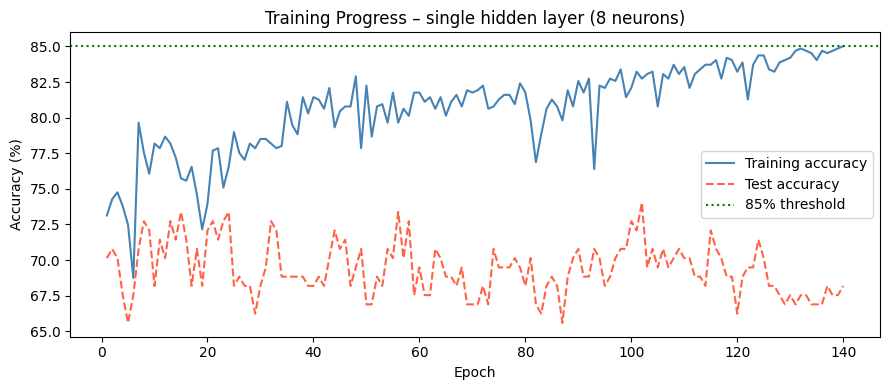

In [ ]:

plt.figure(figsize=(9, 4))
plt.plot(history['epoch'], [a*100 for a in history['train_acc']],
         label='Training accuracy', color='steelblue')
plt.plot(history['epoch'], [a*100 for a in history['test_acc']],
         label='Test accuracy', color='tomato', linestyle='--')
plt.axhline(SUCCESS_THRESHOLD * 100, color='green', linestyle=':', linewidth=1.5,
            label=f'{SUCCESS_THRESHOLD*100:.0f}% threshold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Progress – single hidden layer (8 neurons)')
plt.legend()
plt.tight_layout()
plt.savefig('training_curve_single.png', dpi=120)
plt.show()

In [ ]:
results = []  

for hidden_layers in HIDDEN_CONFIGS:

   
    arch = [N_features] + hidden_layers + [1]
    label = str(hidden_layers)  

    print(f"\n{'='*55}")
    print(f"Testing architecture: {arch}")
    print(f"{'='*55}")

    model = NeuralNetwork(layer_sizes=arch, eta=ETA)
    hist  = model.train(
        X_train, y_train,
        X_test,  y_test,
        max_epochs        = MAX_EPOCHS,
        success_threshold = SUCCESS_THRESHOLD
    )

    final_train = model.accuracy(X_train, y_train)
    final_test  = model.accuracy(X_test,  y_test)
    epochs_used = len(hist['epoch'])

    results.append({
        'config'     : label,
        'arch'       : arch,
        'train_acc'  : final_train,
        'test_acc'   : final_test,
        'epochs'     : epochs_used,
        'history'    : hist,
    })

print("\n" + "="*55)
print("SUMMARY")
print("="*55)
print(f"{'Hidden config':<15} {'Train acc':>10} {'Test acc':>10} {'Epochs':>8}")
print("-"*55)
for r in results:
    print(f"{r['config']:<15} {r['train_acc']*100:>9.1f}% "
          f"{r['test_acc']*100:>9.1f}% {r['epochs']:>8}")


best = max(results, key=lambda r: r['test_acc'])
print(f"\n★ Best architecture: {best['arch']}  "
      f"(test acc = {best['test_acc']*100:.1f}%)")


Testing architecture: [8, 4, 1]
  Epoch    1  |  Train acc:  73.6%  |  Test acc:   73.4%
  Epoch  100  |  Train acc:  81.6%  |  Test acc:   68.8%
  Epoch  200  |  Train acc:  81.3%  |  Test acc:   66.9%
  Epoch  300  |  Train acc:  81.4%  |  Test acc:   66.9%
  Epoch  400  |  Train acc:  81.4%  |  Test acc:   68.2%
  Epoch  500  |  Train acc:  81.6%  |  Test acc:   66.2%
  Epoch  600  |  Train acc:  81.9%  |  Test acc:   65.6%
  Epoch  700  |  Train acc:  81.4%  |  Test acc:   66.9%
  Epoch  800  |  Train acc:  81.4%  |  Test acc:   66.9%
  Epoch  900  |  Train acc:  81.6%  |  Test acc:   65.6%
  Epoch 1000  |  Train acc:  81.6%  |  Test acc:   66.9%
  Epoch 1100  |  Train acc:  82.1%  |  Test acc:   66.2%
  Epoch 1200  |  Train acc:  82.1%  |  Test acc:   68.2%
  Epoch 1300  |  Train acc:  81.9%  |  Test acc:   65.6%
  Epoch 1400  |  Train acc:  81.9%  |  Test acc:   66.9%
  Epoch 1500  |  Train acc:  81.9%  |  Test acc:   66.2%
  Epoch 1600  |  Train acc:  82.4%  |  Test acc:   67.5

In [188]:
def sigmoid(s):

    return 1.0 / (1.0 + np.exp(-np.clip(s, -500, 500)))


def logistic_regression_train(X, y_raw, eta=0.1, max_iter=2000):

    N, d = X.shape
    w = np.zeros(d) 

    for _ in range(max_iter):
        scores = y_raw * (X @ w)                  
        grads  = -y_raw * sigmoid(-scores)  
        grad   = grads @ X / N                
        w     -= eta * grad                    

    return w


def logistic_regression_accuracy(X, y, w):
   
    probs = sigmoid(X @ w)                       
    preds = np.where(probs >= 0.5, 1.0, -1.0)   
    return (preds == y).mean()



print("Training logistic regression (from scratch, batch GD)...")
w_lr = logistic_regression_train(X_train, y_train, eta=ETA, max_iter=2000)

lr_train_acc = logistic_regression_accuracy(X_train, y_train, w_lr)
lr_test_acc  = logistic_regression_accuracy(X_test,  y_test,  w_lr)
print(f"  Logistic Regression –"
      f"Test: {lr_test_acc*100:.2f}%")


best_nn_test = best['test_acc']
best_nn_arch = best['arch']
print(f"  Best Neural Network   – Test: {best_nn_test*100:.2f}%  "
      f"  (architecture: {best_nn_arch})")

Training logistic regression (from scratch, batch GD)...
  Logistic Regression –Test: 68.83%
  Best Neural Network   – Test: 74.68%    (architecture: [8, 8, 8, 4, 1])
